# `geom_bracket()`

In [1]:
import pandas as pd

from lets_plot import *


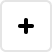
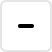
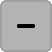
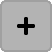
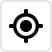
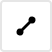
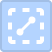
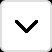
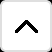
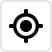
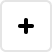
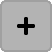
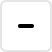
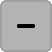
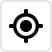
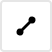
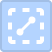
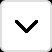
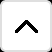
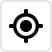

In [2]:
LetsPlot.setup_html()

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/JetBrains/lets-plot-docs/refs/heads/master/data/mpg.csv")
print(df.shape)
df.head()

(234, 12)


,Unnamed: 0,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
0,1,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,2,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
2,3,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
3,4,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
4,5,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact


In [4]:
p = ggplot(df, aes("drv", "hwy")) + geom_boxplot()
grouped_p = ggplot(df, aes(x="drv", y="hwy")) + geom_boxplot(aes(fill=as_discrete("year")))

## Basic Plot: `geom_bracket()`

In [5]:
bracket_data = {
    "xmin": ["f", "f"],
    "xmax": ["4", "r"],
    "y": [46, 48],
    "lower_y": [10, 8],
    "label": [0.01, 0.02],
    "g": ["A", "B"]
}

bracket_plot = p + geom_bracket(aes(xmin="xmin", xmax="xmax", y="y", label="label"), data=bracket_data)
bracket_plot

## Basic Plot: `geom_bracket_dodge()`

In [6]:
bracket_dodge_data = {
    "x": ["f", "4", "r"],
    "y": [46, 30, 28],
    "lower_y": [15, 10, 13],
    "start": [0, 0, 0],
    "end": [1, 1, 1],
    "label": [0.01, 0.02, 0.03],
    "g": ["A", "B", "C"],
}

bracket_dodge_plot = grouped_p + geom_bracket_dodge(aes("x", "y", istart="start", iend="end", label="label"), data=bracket_dodge_data)
bracket_dodge_plot

## Orientation: `geom_bracket()`

In [7]:
ggplot() + \
    geom_boxplot(aes("hwy", "drv"), data=df) + \
    geom_bracket(aes(ymin="xmin", ymax="xmax", x="y", label="label"), data=bracket_data)

## Orientation: `geom_bracket_dodge()`

In [8]:
ggplot(df, aes("hwy", "drv")) + \
    geom_boxplot(aes(fill=as_discrete("year"))) + \
    geom_bracket_dodge(aes("y", "x", istart="start", iend="end", label="label"), data=bracket_dodge_data)

## Remove Label: `geom_bracket()`

In [9]:
gggrid([
    p + geom_bracket(aes(xmin="xmin", xmax="xmax", y="y", label="label"), data=bracket_data),
    p + geom_bracket(aes(xmin="xmin", xmax="xmax", y="y"), data=bracket_data),
    p + geom_bracket(aes(xmin="xmin", xmax="xmax", y="y", label="label"), data=bracket_data, size=0),
    p + geom_bracket(aes(xmin="xmin", xmax="xmax", y="y", label="label"), data=bracket_data, alpha=0, segment_alpha=1),
], ncol=2)

## Remove Label: `geom_bracket_dodge()`

In [10]:
gggrid([
    grouped_p + geom_bracket_dodge(aes("x", "y", istart="start", iend="end", label="label"), data=bracket_dodge_data),
    grouped_p + geom_bracket_dodge(aes("x", "y", istart="start", iend="end"), data=bracket_dodge_data),
    grouped_p + geom_bracket_dodge(aes("x", "y", istart="start", iend="end", label="label"), data=bracket_dodge_data, size=0),
    grouped_p + geom_bracket_dodge(aes("x", "y", istart="start", iend="end", label="label"), data=bracket_dodge_data, alpha=0, segment_alpha=1),
], ncol=2)

## Aesthetics

### Own Aesthetics

#### `lenstart`/`lenend`

In [11]:
gggrid([
    p + geom_bracket(aes(xmin="xmin", xmax="xmax", y="y", label="label"), data=bracket_data) + \
        ggtitle("Default"),
    p + geom_bracket(aes(xmin="xmin", xmax="xmax", y="y", label="label", lenend=[40, 50]), data=bracket_data) + \
        ggtitle("aes(lenend=...)"),
    p + geom_bracket(aes(xmin="xmin", xmax="xmax", y="y", label="label"), data=bracket_data, lenend=15) + \
        ggtitle("lenend=15"),
    p + geom_bracket(aes(xmin="xmin", xmax="xmax", y="lower_y", label="label"), data=bracket_data, lenstart=-5, lenend=-5) + \
        ggtitle("tiplength_xxx=-5"),
    p + geom_bracket(aes(xmin="xmin", xmax="xmax", y="lower_y", label="label"), data=bracket_data, lenstart=-5) + \
        ggtitle("lenstart=-5"),
], ncol=2)

### Text Aesthetics

In [12]:
def aes_plots(name, const_value, value="g", const=False):
    bracket_mapping = dict(xmin="xmin", xmax="xmax", y="y", label="label")
    bracket_dodge_mapping = dict(x="x", y="y", istart="start", iend="end", label="label")
    plots = [
        p + geom_bracket(aes(**{**bracket_mapping, **{name: value}}), data=bracket_data) + ggtitle(f"aes({name}='{value}')"),
        p + geom_bracket(aes(**bracket_mapping), data=bracket_data, **{name: const_value}) + ggtitle(f"{name}: {const_value}"),
        grouped_p + geom_bracket_dodge(aes(**{**bracket_dodge_mapping, **{name: value}}), data=bracket_dodge_data) + ggtitle(f"aes({name}='{value}')"),
        grouped_p + geom_bracket_dodge(aes(**bracket_dodge_mapping), data=bracket_dodge_data, **{name: const_value}) + ggtitle(f"{name}: {const_value}"),
    ]
    if const:
        return [plot for i, plot in enumerate(plots) if i % 2 == 1]
    else:
        return plots

In [13]:
gggrid(aes_plots("alpha", .5), ncol=2)

In [14]:
gggrid(aes_plots("color", "green"), ncol=2)

In [15]:
gggrid(aes_plots("size", 5), ncol=2)

In [16]:
gggrid(aes_plots("family", "courier", const=True))

In [17]:
gggrid(aes_plots("fontface", 'bold_italic', const=True))

In [18]:
gggrid([
    gggrid(aes_plots("hjust", 0, const=True)),
    gggrid(aes_plots("hjust", .5, const=True)),
    gggrid(aes_plots("hjust", 1, const=True)),
], ncol=1)

In [19]:
gggrid([
    gggrid(aes_plots("vjust", 0, const=True)),
    gggrid(aes_plots("vjust", .5, const=True)),
    gggrid(aes_plots("vjust", 1, const=True)),
], ncol=1)

In [20]:
gggrid([
    p + geom_bracket(aes(xmin="xmin", xmax="xmax", y="lower_y", label="label"), data=bracket_data,
                     lenstart=-5, lenend=-5, vjust=2) + \
        ggtitle("tiplength_xxx=-5, vjust=2"),
    grouped_p + geom_bracket_dodge(aes("x", "lower_y", istart="start", iend="end", label="label"), data=bracket_dodge_data,
                                   lenstart=-5, lenend=-5, vjust=2) + \
        ggtitle("tiplength_xxx=-5, vjust=2"),
])

In [21]:
gggrid(aes_plots("angle", 30, const=True))

In [22]:
gggrid([
    ggplot() + geom_bracket(xmin=-1, xmax=1, label="ABC\nDEF") + ggtitle("Default lineheight"),
    ggplot() + geom_bracket(xmin=-1, xmax=1, label="ABC\nDEF", lineheight=2) + ggtitle("lineheight=2"),
    ggplot() + geom_bracket_dodge(x=0, istart=0, iend=1, label="ABC\nDEF") + ggtitle("Default lineheight"),
    ggplot() + geom_bracket_dodge(x=0, istart=0, iend=1, label="ABC\nDEF", lineheight=2) + ggtitle("lineheight=2"),
], ncol=2) + ggtitle("Multiline label")

### Segment Aesthetics

In [23]:
gggrid(aes_plots("linetype", 'dotted'), ncol=2)

In [24]:
gggrid(aes_plots("segment_color", "green"), ncol=2)

In [25]:
gggrid(aes_plots("segment_size", 4), ncol=2)

In [26]:
gggrid(aes_plots("segment_alpha", .5), ncol=2)

## Parameters

### Own Parameters

#### `bracket_shorten`

In [27]:
gggrid([
    p + geom_bracket(aes(xmin="xmin", xmax="xmax", y="y", label="label"), data=bracket_data) + ggtitle("Default"),
    p + geom_bracket(aes(xmin="xmin", xmax="xmax", y="y", label="label"), data=bracket_data, bracket_shorten=.1) + ggtitle("bracket_shorten=.1"),
    p + geom_bracket(aes(xmin="xmin", xmax="xmax", y="y", label="label"), data=bracket_data, bracket_shorten=.9) + ggtitle("bracket_shorten=.9"),
])

In [28]:
gggrid([
    grouped_p + geom_bracket_dodge(aes("x", "y", istart="start", iend="end", label="label"),
                                   data=bracket_dodge_data) + ggtitle("Default"),
    grouped_p + geom_bracket_dodge(aes("x", "y", istart="start", iend="end", label="label"),
                                   data=bracket_dodge_data, bracket_shorten=.1) + ggtitle("bracket_shorten=.1"),
    grouped_p + geom_bracket_dodge(aes("x", "y", istart="start", iend="end", label="label"),
                                   data=bracket_dodge_data, bracket_shorten=.9) + ggtitle("bracket_shorten=.9"),
])

#### `tiplength_unit`

In [29]:
gggrid([
    p + geom_bracket(aes(xmin="xmin", xmax="xmax", y="y", label="label"), data=bracket_data) + \
        ggtitle("Default"),
    p + geom_bracket(aes(xmin="xmin", xmax="xmax", y="y", label="label"), data=bracket_data, tiplength_unit='px') + \
        ggtitle("tiplength_unit='px'"),
    p + geom_bracket(aes(xmin="xmin", xmax="xmax", y="y", label="label"), data=bracket_data, tiplength_unit='identity') + \
        ggtitle("tiplength_unit='identity'"),
])

In [30]:
gggrid([
    grouped_p + geom_bracket_dodge(aes("x", "y", istart="start", iend="end", label="label"),
                                   data=bracket_dodge_data) + ggtitle("Default"),
    grouped_p + geom_bracket_dodge(aes("x", "y", istart="start", iend="end", label="label"),
                                   data=bracket_dodge_data, tiplength_unit='px') + \
        ggtitle("tiplength_unit='px'"),
    grouped_p + geom_bracket_dodge(aes("x", "y", istart="start", iend="end", label="label"),
                                   data=bracket_dodge_data, tiplength_unit='identity') + \
        ggtitle("tiplength_unit='identity'"),
])

#### `dodge_width`

In [31]:
ggplot(df, aes("drv", "hwy")) + \
    geom_boxplot(aes(fill=as_discrete("year")), width=.2, position=position_dodge(width=.3)) + \
    geom_bracket_dodge(aes("x", "y", istart="start", iend="end", label="label"), data=bracket_dodge_data, dodge_width=.3)

#### `ngroup`

In [32]:
class_hwy_cyl_plot = ggplot() + geom_boxplot(aes("class", "hwy", fill=as_discrete("cyl")), data=df)

class_hwy_cyl_bracket_dodge_data = {
    "x": ["subcompact"],
    "y": [50],
    "start": [0],
    "end": [1],
    "label": [0.01],
}

gggrid([
    class_hwy_cyl_plot + geom_bracket_dodge(aes("x", "y", istart="start", iend="end", label="label"),
                                            data=class_hwy_cyl_bracket_dodge_data) + ggtitle("Default"),
    class_hwy_cyl_plot + geom_bracket_dodge(aes("x", "y", istart="start", iend="end", label="label"),
                                            data=class_hwy_cyl_bracket_dodge_data, ngroup=4) + \
        ggtitle("ngroup=4"),
], ncol=1)

### Text Parameters

#### `label_format`

In [33]:
p + geom_bracket(aes(xmin="xmin", xmax="xmax", y="y", label="label"), data=bracket_data, label_format=".2~e")

In [34]:
grouped_p + geom_bracket_dodge(aes("x", "y", istart="start", iend="end", label="label"), data=bracket_dodge_data, label_format=".2~e")

#### `na_text`

In [35]:
bracket_na_data = {
    "xmin": ["f", "f"],
    "xmax": ["4", "r"],
    "y": [46, 48],
    "label": [0.01, None],
    "g": ["A", "B"]
}

gggrid([
    p + geom_bracket(aes(xmin="xmin", xmax="xmax", y="y", label="label"), data=bracket_na_data),
    p + geom_bracket(aes(xmin="xmin", xmax="xmax", y="y", label="label"), data=bracket_na_data, na_text="None"),
])

In [36]:
bracket_dodge_na_data = {
    "x": ["f", "4", "r"],
    "y": [46, 30, 28],
    "start": [0, 0, 0],
    "end": [1, 1, 1],
    "label": [0.01, 0.02, None],
}

gggrid([
    grouped_p + geom_bracket_dodge(aes("x", "y", istart="start", iend="end", label="label"), data=bracket_dodge_na_data),
    grouped_p + geom_bracket_dodge(aes("x", "y", istart="start", iend="end", label="label"), data=bracket_dodge_na_data, na_text="None"),
])

#### `nudge_x`/`nudge_y`, `nudge_unit`

In [37]:
gggrid([
    p + geom_bracket(aes(xmin="xmin", xmax="xmax", y="y", label="label"), data=bracket_data) + ggtitle("Default"),
    p + geom_bracket(aes(xmin="xmin", xmax="xmax", y="y", label="label"), data=bracket_data, nudge_y=-2) + ggtitle("nudge_y=-2"),
    p + geom_bracket(aes(xmin="xmin", xmax="xmax", y="y", label="label"), data=bracket_data, nudge_x=.5) + ggtitle("nudge_x=.5"),
    p + geom_bracket(aes(xmin="xmin", xmax="xmax", y="y", label="label"), data=bracket_data, nudge_x=10, nudge_unit='px') + \
        ggtitle("nudge_x=10, nudge_unit='px'"),
], ncol=2)

In [38]:
gggrid([
    grouped_p + geom_bracket_dodge(aes("x", "y", istart="start", iend="end", label="label"), data=bracket_dodge_data) + ggtitle("Default"),
    grouped_p + geom_bracket_dodge(aes("x", "y", istart="start", iend="end", label="label"), data=bracket_dodge_data, nudge_y=-2) + ggtitle("nudge_y=-2"),
    grouped_p + geom_bracket_dodge(aes("x", "y", istart="start", iend="end", label="label"), data=bracket_dodge_data, nudge_x=.5) + ggtitle("nudge_x=.5"),
    grouped_p + geom_bracket_dodge(aes("x", "y", istart="start", iend="end", label="label"), data=bracket_dodge_data, nudge_x=10, nudge_unit='px') + \
        ggtitle("nudge_x=10, nudge_unit='px'"),
], ncol=2)

#### `size_unit`

In [39]:
gggrid([
    p + geom_bracket(aes(xmin="xmin", xmax="xmax", y="y", label="label"), data=bracket_data, size=5) + ggtitle("Default size_unit"),
    p + geom_bracket(aes(xmin="xmin", xmax="xmax", y="y", label="label"), data=bracket_data, size=5, size_unit='y') + ggtitle("size_unit='y'"),
]) + ggsize(800, 600)

In [40]:
gggrid([
    grouped_p + geom_bracket_dodge(aes("x", "y", istart="start", iend="end", label="label"), data=bracket_dodge_data) + ggtitle("Default size_unit"),
    grouped_p + geom_bracket_dodge(aes("x", "y", istart="start", iend="end", label="label"), data=bracket_dodge_data, size_unit='y') + \
        ggtitle("size_unit='y'"),
]) + ggsize(800, 400)

### Standard Parameters

#### `position`

In [41]:
gggrid([
    p + geom_bracket(aes(xmin="xmin", xmax="xmax", y="y", label="label"), data=bracket_data, position=position_nudge(x=.25)) + \
        ggtitle("position_nudge(x=.25)"),
    p + geom_bracket(aes(xmin="xmin", xmax="xmax", y="y", label="label"), data=bracket_data, position=position_nudge(y=-2)) + \
        ggtitle("position_nudge(y=-2)"),
    grouped_p + geom_bracket_dodge(aes("x", "y", istart="start", iend="end", label="label"), data=bracket_dodge_data, position=position_nudge(x=.25)) + \
        ggtitle("position_nudge(x=.25)"),
    grouped_p + geom_bracket_dodge(aes("x", "y", istart="start", iend="end", label="label"), data=bracket_dodge_data, position=position_nudge(y=-2)) + \
        ggtitle("position_nudge(y=-2)"),
], ncol=2)

#### `show_legend`

In [42]:
p + geom_bracket(aes(xmin="xmin", xmax="xmax", y="y", label="label",
                     size="g", angle="g", linetype="g", segment_color="g", segment_alpha="g", segment_size="g"),
                 data=bracket_data, show_legend=True)

#### `manual_key`

In [43]:
p + geom_bracket(aes(xmin="xmin", xmax="xmax", y="y", label="label"), data=bracket_data, color="blue", manual_key="p-value")

#### `sampling`

In [44]:
p + geom_bracket(aes(xmin="xmin", xmax="xmax", y="y", label="label"), data=bracket_data, sampling=sampling_random(1))

#### `color_by`

In [45]:
p + geom_bracket(aes(xmin="xmin", xmax="xmax", y="y", label="label", paint_a="g"), data=bracket_data, color_by="paint_a")

## Interaction With Other Layers

### Marginal

In [46]:
gggrid([
    bracket_plot + ggmarginal("r", layer=geom_histogram()),
    bracket_dodge_plot + ggmarginal("r", layer=geom_histogram(aes(fill=as_discrete("year"))))
])

### Toolbar

In [47]:
gggrid([
    bracket_plot,
    bracket_dodge_plot,
]) + ggtb()

### Facets

In [48]:
bracket_facet_data = {
    "xmin": ["f", "f", "f", "f"],
    "xmax": ["4", "4", "r", "r"],
    "y": [50, 50, 56, 56],
    "label": [0.01, 0.03, 0.02, 0.04],
    "year": [1999, 2008, 1999, 2008]
}

grouped_p + \
    geom_bracket(aes(xmin="xmin", xmax="xmax", y="y", label="label", color=as_discrete("year")), data=bracket_facet_data) + \
    facet_grid(x="year")

In [49]:
bracket_grouped_facet_data = {
    "x": ["f", "4", "r"],
    "y": [46, 30, 28],
    "start": [0, 0, 0],
    "end": [1, 1, 1],
    "label": [0.01, 0.02, 0.03],
    "cyl": [4, 4, 8],
}

ggplot(df, aes(x="drv", y="hwy")) + geom_boxplot(aes(fill=as_discrete("year"))) + \
    geom_bracket_dodge(aes("x", "y", istart="start", iend="end", label="label"), data=bracket_grouped_facet_data) + \
    facet_wrap("cyl")

### Coordinate Systems

#### Flip

In [50]:
gggrid([
    bracket_plot + coord_flip(),
    bracket_dodge_plot + coord_flip(),
])

## Tests

### Boundary tests

In [51]:
tests = [
    {
        'title': "Empty data",
        'data': {
            'xmin': [],
            'xmax': [],
            'y': [],
            'label': [],
        }
    },
    {
        'title': "One element",
        'data': {
            'xmin': [0],
            'xmax': [1],
            'y': [0],
            'label': ["a"],
        }
    },
    {
        'title': "NaN's in data",
        'data': {
            'xmin': [0, None, 0, 0, 0],
            'xmax': [1, 1, None, 1, 1],
            'y': [0, 1, 2, None, 4],
            'label': ["a", "a", "a", "a", None],
        }
    },
]

gggrid([
    ggplot(t['data']) + \
        geom_bracket(aes(xmin='xmin', xmax='xmax', y='y', label='label')) + \
        ggtitle(t['title'])
    for t in tests
], ncol=2)

In [52]:
tests = [
    {
        'title': "Empty data",
        'data': {
            'x': [],
            'y': [],
            'start': [],
            'end': [],
            'label': [],
        }
    },
    {
        'title': "One element",
        'data': {
            'x': [0],
            'y': [0],
            'start': [0],
            'end': [1],
            'label': ["a"],
        }
    },
    {
        'title': "NaN's in data",
        'data': {
            'x': [0, None, 2, 3, 4, 5],
            'y': [0, 1, None, 3, 4, 5],
            'start': [0, 0, 0, None, 0, 0],
            'end': [1, 1, 1, 1, None, 1],
            'label': ["a", "b", "c", "d", "e", None],
        }
    },
]

gggrid([
    ggplot(t['data']) + \
        geom_bracket_dodge(aes('x', 'y', istart='start', iend='end', label='label')) + \
        ggtitle(t['title'])
    for t in tests
], ncol=2)

### Regressions

In [53]:
def get_test_plot(dy, shift):
    y_base = shift * dy
    box_data = {
        "x": ["A", "B", "C"],
        "y": [y_base, y_base + dy, y_base - dy],
        "ymin": [y_base - 5 * dy, y_base - 4 * dy, y_base - 6 * dy],
        "ymax": [y_base + 5 * dy, y_base + 6 * dy, y_base + 4 * dy],
    }
    bracket_data = {
        "xmin": ["A", "A"],
        "xmax": ["B", "C"],
        "y": [y_base + 7 * dy, y_base + 8 * dy],
        "label": [0.01, 0.02],
    }
    return ggplot() + \
        geom_crossbar(aes(x="x", y="y", ymin="ymin", ymax="ymax"), data=box_data) + \
        geom_bracket(aes(xmin="xmin", xmax="xmax", y="y", label="label"), data=bracket_data)

gggrid([
    get_test_plot(1e-11, 3.14e6),
    get_test_plot(1e-11, -3.14e6),
    get_test_plot(1e11, 3.14e6),
    get_test_plot(1e11, -3.14e6),
], ncol=2)

In [54]:
gggrid([
    grouped_p + geom_bracket_dodge(aes(y="y", istart="start", iend="end", label="label"), data=bracket_dodge_data),
    grouped_p + geom_bracket_dodge(aes(y="y", istart="start", iend="end", label="label"), data=bracket_dodge_data, x=1),
], ncol=1)

In [55]:
grouped_p + geom_bracket_dodge(aes("x", "y", istart="start", iend="end", label="label"), data=bracket_dodge_data, dodge_width=0)

## Problems

### Group by multiple variables

In [56]:
bracket_multi_grouped_data = {
    "x": ["f", "4", "r"],
    "y": [46, 27, 28],
    "start": [0, 2, 4],
    "end": [1, 3, 5],
    "label": [0.01, 0.02, 0.03],
}

multi_p = ggplot(df, aes(x="drv", y="hwy")) + \
    geom_boxplot(aes(fill=as_discrete("cyl"), alpha=as_discrete("year"))) + \
    scale_alpha(range=[.5, 1])

gggrid([
    multi_p + geom_bracket_dodge(aes("x", "y", istart="start", iend="end", label="label"), data=bracket_multi_grouped_data) + ggtitle("Default"),
    multi_p + geom_bracket_dodge(aes("x", "y", istart="start", iend="end", label="label"), data=bracket_multi_grouped_data, ngroup=7) + \
        ggtitle("ngroup=7"),
], ncol=1)